Vamos a utilizar el dataset Planetary Systems obtenido de [aquí](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PS)

In [467]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = pd.read_csv("C:/TFM_Data/PS_2026.03.04_10.57.52.csv",header=46)

print(data.columns)

print(data.head)

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbsmax', 'pl_rade',
       'pl_radj', 'pl_bmasse', 'pl_bmassj', 'pl_bmassprov', 'pl_orbeccen',
       'pl_insol', 'pl_eqt', 'ttv_flag', 'st_refname', 'st_spectype',
       'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_metratio', 'st_logg',
       'sy_refname', 'rastr', 'ra', 'decstr', 'dec', 'sy_dist', 'sy_vmag',
       'sy_kmag', 'sy_gaiamag', 'rowupdate', 'pl_pubdate', 'releasedate'],
      dtype='str')
<bound method NDFrame.head of          pl_name hostname  default_flag  sy_snum  sy_pnum  discoverymethod  \
0       11 Com b   11 Com             1        2        1  Radial Velocity   
1       11 Com b   11 Com             0        2        1  Radial Velocity   
2       11 Com b   11 Com             0        2        1  Radial Velocity   
3       11 UMi b   11 UMi             0        1        

Veamos ahora qué forma tienen estos datos.

In [468]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 39443 entries, 0 to 39442
Data columns (total 42 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          39443 non-null  str    
 1   hostname         39443 non-null  str    
 2   default_flag     39443 non-null  int64  
 3   sy_snum          39443 non-null  int64  
 4   sy_pnum          39443 non-null  int64  
 5   discoverymethod  39443 non-null  str    
 6   disc_year        39441 non-null  float64
 7   disc_facility    39443 non-null  str    
 8   soltype          39443 non-null  str    
 9   pl_controv_flag  39443 non-null  int64  
 10  pl_refname       39443 non-null  str    
 11  pl_orbper        36122 non-null  float64
 12  pl_orbsmax       22114 non-null  float64
 13  pl_rade          27162 non-null  float64
 14  pl_radj          27162 non-null  float64
 15  pl_bmasse        7263 non-null   float64
 16  pl_bmassj        7262 non-null   float64
 17  pl_bmassprov     7263 n

La tercera columna, default_flag, parece indicar el estándar de cada planeta. Dado que muchos de ellos están duplicados, voy a mantener solo los que tengan un 1 en estos valores. Además, voy a eliminar las columnas que tratan sobre la última actualización, fecha de publicación y todas las referencias planetarias, estelares y de sistema ya que no son tan relevantes como el resto.

In [469]:
data.drop(data[data["default_flag"]==0].index,axis=0, inplace=True)
data.info()
data.drop(["rowupdate","pl_pubdate","releasedate","sy_refname","pl_refname","st_refname","default_flag"],axis=1, inplace=True)
data.info()

<class 'pandas.DataFrame'>
Index: 6128 entries, 0 to 39442
Data columns (total 42 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6128 non-null   str    
 1   hostname         6128 non-null   str    
 2   default_flag     6128 non-null   int64  
 3   sy_snum          6128 non-null   int64  
 4   sy_pnum          6128 non-null   int64  
 5   discoverymethod  6128 non-null   str    
 6   disc_year        6127 non-null   float64
 7   disc_facility    6128 non-null   str    
 8   soltype          6128 non-null   str    
 9   pl_controv_flag  6128 non-null   int64  
 10  pl_refname       6128 non-null   str    
 11  pl_orbper        5787 non-null   float64
 12  pl_orbsmax       3829 non-null   float64
 13  pl_rade          4561 non-null   float64
 14  pl_radj          4561 non-null   float64
 15  pl_bmasse        3035 non-null   float64
 16  pl_bmassj        3035 non-null   float64
 17  pl_bmassprov     3035 non-nul

Ahora mismo, hemos reducido la cantidad de datos a tan solo 6128 filas, 35 columnas. De estas columnas, algunas son datos dados en distintas unidades, como es el caso de pl_bmasse y pl_bmassj, decstr y dec, rastr y ra, etc. En este caso, las que acaban en str son variables en sexagesimal, y están en formato string, por lo que analizar sus datos será más complicado. Teniendo en cuenta que los mismos datos están dados en forma float64 en otras columnas, vamos a eliminarlas. También escojo eliminar la masa y el radio de los exoplanetas en función de Júpiter, solo por reducir el número de columnas.

In [470]:
data.drop(["rastr","decstr","pl_bmassj","pl_radj"],axis=1,inplace=True)

print(data.columns)

Index(['pl_name', 'hostname', 'sy_snum', 'sy_pnum', 'discoverymethod',
       'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_orbper',
       'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_bmassprov', 'pl_orbeccen',
       'pl_insol', 'pl_eqt', 'ttv_flag', 'st_spectype', 'st_teff', 'st_rad',
       'st_mass', 'st_met', 'st_metratio', 'st_logg', 'ra', 'dec', 'sy_dist',
       'sy_vmag', 'sy_kmag', 'sy_gaiamag'],
      dtype='str')


pl_bmassprov indica la forma que tiene la masa en los datos, siendo las opciones las siguientes.

In [471]:
data["pl_bmassprov"].value_counts()

pl_bmassprov
Mass              2051
Msini              974
Msin(i)/sin(i)      10
Name: count, dtype: int64

Por lo tanto, conviene mantener esta columna. Si nos interesa reducir el dataset aún más, podríamos eliminar todos los datos en los que pl_controv_flag == True, ya que esto implica que su hallazgo está debatido, y quizá no convendría analizarlo con el resto de datos.

In [472]:
data.drop(data[data["pl_controv_flag"]==1].index,axis=0, inplace=True)
data.drop(["pl_controv_flag"],axis=1,inplace=True)

data.info()

<class 'pandas.DataFrame'>
Index: 6080 entries, 0 to 39442
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6080 non-null   str    
 1   hostname         6080 non-null   str    
 2   sy_snum          6080 non-null   int64  
 3   sy_pnum          6080 non-null   int64  
 4   discoverymethod  6080 non-null   str    
 5   disc_year        6079 non-null   float64
 6   disc_facility    6080 non-null   str    
 7   soltype          6080 non-null   str    
 8   pl_orbper        5742 non-null   float64
 9   pl_orbsmax       3785 non-null   float64
 10  pl_rade          4550 non-null   float64
 11  pl_bmasse        2997 non-null   float64
 12  pl_bmassprov     2997 non-null   str    
 13  pl_orbeccen      2560 non-null   float64
 14  pl_insol         913 non-null    float64
 15  pl_eqt           1691 non-null   float64
 16  ttv_flag         6080 non-null   int64  
 17  st_spectype      1322 non-nul

De esta manera, hemos reducido el dataset a tan solo 6080 planetas, con 30 columnas de datos. Los datos se agrupan en:
<ul>
    <li>Concernientes al planeta (pl)</li>
    <li>Concernientes a la estrella que orbita (st)</li>
    <li>Concernientes al sistema estrella-planeta (sy)</li>
    <li>Concernientes al descubrimiento (disc)</li>
</ul>

Existen excepciones, como hostname o soltype, que se refieren al nombre y tipo de la estrella a la que orbita el planeta, pero no empiezan por st, o ra y dec, cuyo significado desconozco. También está ttv_flag, que indica si un planeta tiene variaciones en su velocidad de tránsito por delante de la estrella. Para mantener coherencia, renombraremos todas las columnas para que tengan el prefijo adecuado.

In [473]:
data.rename(columns={"hostname":"st_name","soltype":"st_type","discoverymethod":"disc_method"},inplace=True)

print(data.columns)

Index(['pl_name', 'st_name', 'sy_snum', 'sy_pnum', 'disc_method', 'disc_year',
       'disc_facility', 'st_type', 'pl_orbper', 'pl_orbsmax', 'pl_rade',
       'pl_bmasse', 'pl_bmassprov', 'pl_orbeccen', 'pl_insol', 'pl_eqt',
       'ttv_flag', 'st_spectype', 'st_teff', 'st_rad', 'st_mass', 'st_met',
       'st_metratio', 'st_logg', 'ra', 'dec', 'sy_dist', 'sy_vmag', 'sy_kmag',
       'sy_gaiamag'],
      dtype='str')


Una vez reducido el dataset, podemos empezar a tratar los NaN. Debido a los formatos distintos de las columnas, no podemos aplicar un reemplazo general de NaN. Por lo tanto, es necesario ir caso por caso para estudiar el valor que conviene para reemplazar o si conviene siquiera reemplazar el valor. 

Por ejemplo, reemplazar los datos numéricos con 0 no es posible, ya que alteraría en gran medida los resultados de los cálculos estadísticos. Podríamos intentar eliminar todas las filas que tengan al menos un NaN, pero no estoy seguro de que vayan a quedar datos si hacemos esto. Por lo tanto, vamos a guardar los datos viejos también para así hacer comparaciones.

In [474]:
data_old = data.copy(deep=False)

data.dropna(inplace=True)

data.info()
data_old.info()

<class 'pandas.DataFrame'>
Index: 175 entries, 549 to 39291
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pl_name        175 non-null    str    
 1   st_name        175 non-null    str    
 2   sy_snum        175 non-null    int64  
 3   sy_pnum        175 non-null    int64  
 4   disc_method    175 non-null    str    
 5   disc_year      175 non-null    float64
 6   disc_facility  175 non-null    str    
 7   st_type        175 non-null    str    
 8   pl_orbper      175 non-null    float64
 9   pl_orbsmax     175 non-null    float64
 10  pl_rade        175 non-null    float64
 11  pl_bmasse      175 non-null    float64
 12  pl_bmassprov   175 non-null    str    
 13  pl_orbeccen    175 non-null    float64
 14  pl_insol       175 non-null    float64
 15  pl_eqt         175 non-null    float64
 16  ttv_flag       175 non-null    int64  
 17  st_spectype    175 non-null    str    
 18  st_teff        175 non

Nuestro dataset se reduce a 175 planetas, pero quizás podríamos aumentar el número de valores recogiendo los datos de los huecos vacíos de los duplicados antes de eliminarlos. Sin embargo, esto quizá se pasa de dificultad, y es posible que los datos ni siquiera se correspondan con la realidad, ya sea por el uso de métodos distintos para obtener los datos o por otras razones desconocidas. 175 planetas es un dataset perfectamente válido para realizar visualizaciones de datos.

In [475]:
data.describe(include="all")


,pl_name,st_name,sy_snum,sy_pnum,disc_method,disc_year,disc_facility,st_type,pl_orbper,pl_orbsmax,...,st_mass,st_met,st_metratio,st_logg,ra,dec,sy_dist,sy_vmag,sy_kmag,sy_gaiamag
count,175,175,175.000000,175.000000,175,175.000000,175,175,175.000000,175.000000,...,175.000000,175.000000,175,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000
unique,175,132,NaN,NaN,2,NaN,18,1,NaN,NaN,...,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,EPIC 249893012 b,HD 23472,NaN,NaN,Transit,NaN,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,NaN,NaN,...,NaN,NaN,[Fe/H],NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,5,NaN,NaN,173,NaN,117,175,NaN,NaN,...,NaN,NaN,169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.125714,1.942857,NaN,2021.222857,NaN,NaN,18.821736,0.093825,...,0.816433,0.036571,NaN,4.517091,173.764791,-2.038777,182.138278,11.983806,9.241954,11.507803
std,NaN,NaN,0.380821,1.271773,NaN,2.998379,NaN,NaN,83.127568,0.178621,...,0.358522,0.207095,NaN,0.308590,105.905372,49.142697,214.947535,1.958070,1.541914,1.741226
min,NaN,NaN,1.000000,1.000000,NaN,2014.000000,NaN,NaN,0.321923,0.007090,...,0.184400,-0.460000,NaN,3.580000,0.185606,-83.743767,9.412630,7.550000,5.780000,7.576750
25%,NaN,NaN,1.000000,1.000000,NaN,2019.000000,NaN,NaN,2.648767,0.033424,...,0.549000,-0.110000,NaN,4.335000,81.167871,-43.635898,45.043700,10.530500,8.227500,10.389900
50%,NaN,NaN,1.000000,1.000000,NaN,2022.000000,NaN,NaN,4.532000,0.050920,...,0.790000,0.030000,NaN,4.530000,168.226736,-9.607612,110.513000,12.075000,9.184000,11.478500
75%,NaN,NaN,1.000000,2.000000,NaN,2023.000000,NaN,NaN,11.734677,0.089550,...,1.023000,0.185000,NaN,4.730000,277.710853,42.014142,218.085500,13.360000,10.256500,12.587500


La columna st_type parece que solo contiene un tipo de dato, Published Confirmed, por lo que podemos eliminarla tranquilamente. Existen otras columnas que también tienen solo un tipo de dato, por lo que podremos eliminarlas siempre que recordemos qué dato es este. Por ejemplo, pl_bmassprov ahora solo contiene "mass", lo que significa que la masa en la columna pl_bmasse viene solo en kg. Veamos también una gráfica de los distintos años de descubrimiento, junto con los varios métodos:

['st_type', 'pl_bmassprov']


<Axes: xlabel='disc_year', ylabel='Count'>

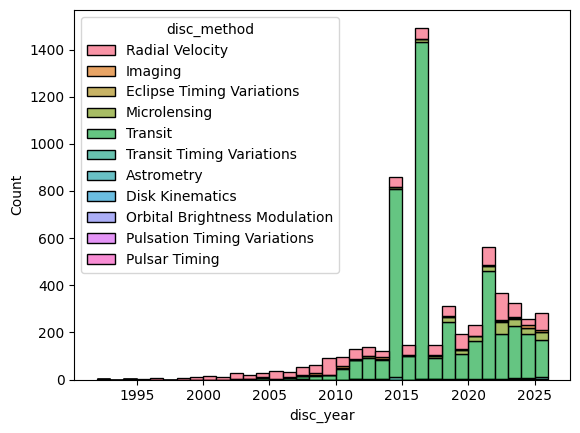

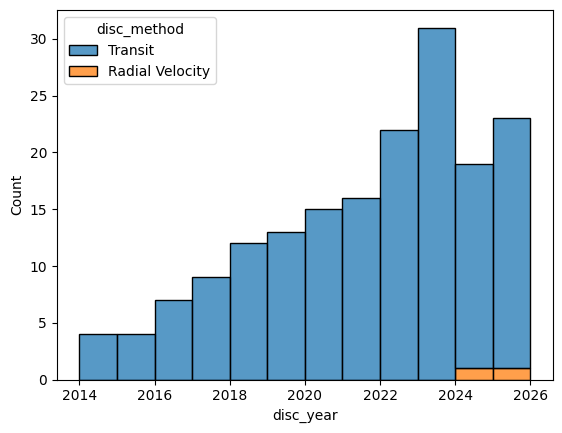

In [476]:
col_borradas = []
for i in data.columns:
    if data[i].nunique() == 1:
        data.drop([i],axis=1,inplace=True)
        col_borradas.append(i)

print(col_borradas)

fig = plt.figure(1)
ax = fig.gca()

sns.histplot(data=data_old,x="disc_year",binwidth=1,hue="disc_method",multiple="stack")

fig = plt.figure(2)
ax = fig.gca()

sns.histplot(data=data,x="disc_year",binwidth=1,hue="disc_method",multiple="stack")

De entre todos los datos disponibles, se puede ver que los más completos fueron descubiertos por tránsito, al reducir la curva de luz proveniente de estas estrellas. Este método es el más comúnmente utilizado para descubrir planetas, como se puede ver en la gráfica.
También podemos ver en qué observatorios se descubren más estrellas.

<Axes: xlabel='Count', ylabel='disc_facility'>

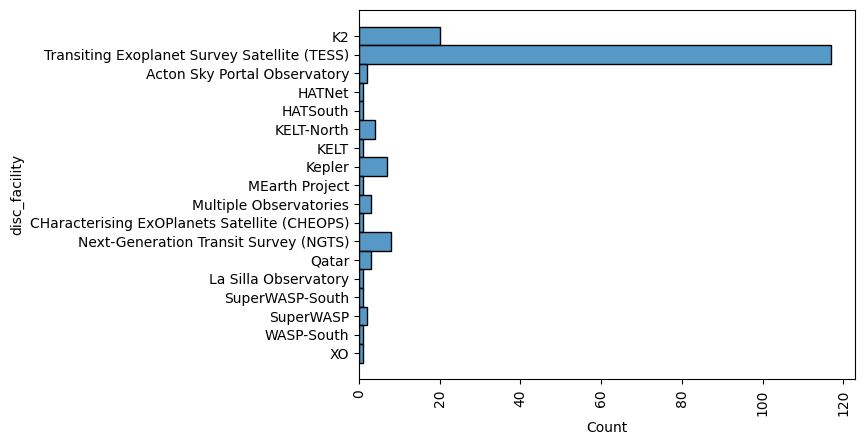

In [477]:
fig = plt.figure(3)
plt.xticks(rotation=90)
ax = fig.gca()
sns.histplot(data=data,y="disc_facility",binwidth=1)

Como podíamos esperar, dado que el método de descubrimiento de la mayoría de planetas ha sido tránsito, el satélite más prolífico ha sido el Transiting Exoplanet Survey Satellite, que utiliza este método para descubrirlos. Si utilizamos el dataset más grande, la gráfica resulta casi imposible de leer. Podemos centrarnos en los diferentes observatorios para ver sus métodos de descubrimiento principales.

In [478]:
data_old["disc_facility"].value_counts()

disc_facility
Kepler                                          2773
Transiting Exoplanet Survey Satellite (TESS)     753
K2                                               549
Multiple Observatories                           330
La Silla Observatory                             293
                                                ... 
Winer Observatory                                  1
Leoncito Astronomical Complex                      1
Infrared Survey Facility                           1
Teide Observatory                                  1
James Webb Space Telescope (JWST)                  1
Name: count, Length: 72, dtype: int64

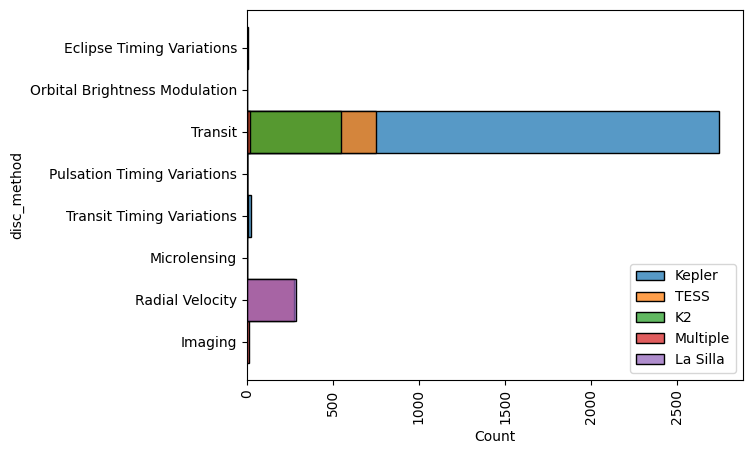

In [479]:
fig = plt.figure(4)
plt.xticks(rotation=90)
ax = fig.gca()
sns.histplot(data=data_old[data_old["disc_facility"] == "Kepler"],y="disc_method",binwidth=1,label="Kepler")
sns.histplot(data=data_old[data_old["disc_facility"] == "Transiting Exoplanet Survey Satellite (TESS)"],y="disc_method",binwidth=1,label="TESS")
sns.histplot(data=data_old[data_old["disc_facility"] == "K2"],y="disc_method",binwidth=1,label="K2")
sns.histplot(data=data_old[data_old["disc_facility"] == "Multiple Observatories"],y="disc_method",binwidth=1,label="Multiple")
sns.histplot(data=data_old[data_old["disc_facility"] == "La Silla Observatory"],y="disc_method",binwidth=1,label="La Silla")
ax.legend()

Cogiendo los 5 principales, se puede ver que la mayoría utilizan el tránsito como herramienta principal, pero otros, como el observatorio de La Silla, se enfocan más en la velocidad radial.

Veamos ahora las características de los planetas.

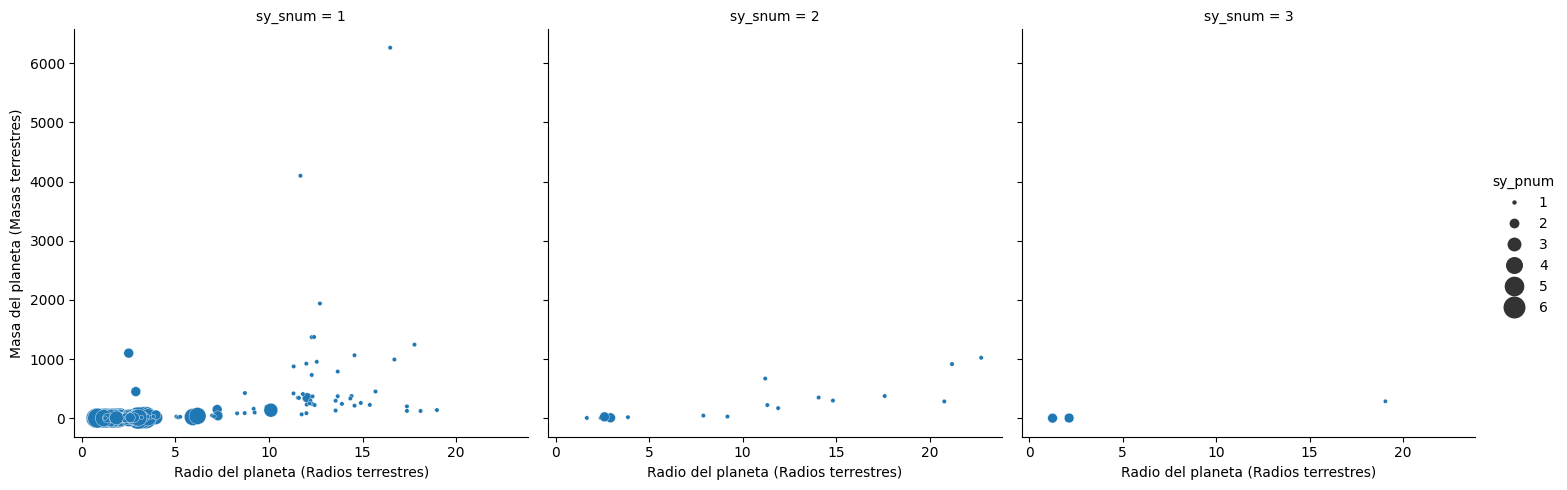

In [480]:
p = sns.relplot(x="pl_rade",y="pl_bmasse",data=data,size="sy_pnum",sizes=[10,50,100,150,200,250],col="sy_snum")
p.set_axis_labels(x_var="Radio del planeta (Radios terrestres)",y_var="Masa del planeta (Masas terrestres)")

Podemos ver que en los sistemas con mayor cantidad de planetas, la masa total se reparte, por lo que el tamaño y la masa de los planetas individuales se ve reducida en comparación con sistemas de menos planetas. Lo mismo se aplica para los sistemas con más estrellas, pero parece que en este caso lo que se ve reducido es solo la masa de los planetas. Es posible que más estrellas se traduzcan en un viento solar más poderoso y mayor poder de atracción, lo que causa que las partículas más ligeras sean expulsadas hacia los extremos del sistema, formando planetas gaseosos, mientras que las más pesadas son atraídas y absorbidas por las estrellas.

Podemos intentar comparar los semiejes mayores y los periodos de los planetas según el número de estrellas para averiguar más sobre esta hipótesis:

<Axes: >

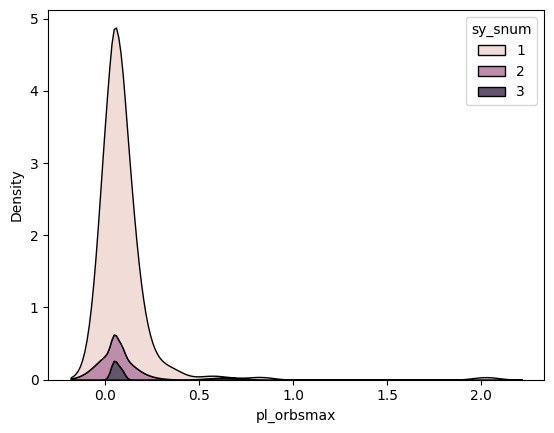

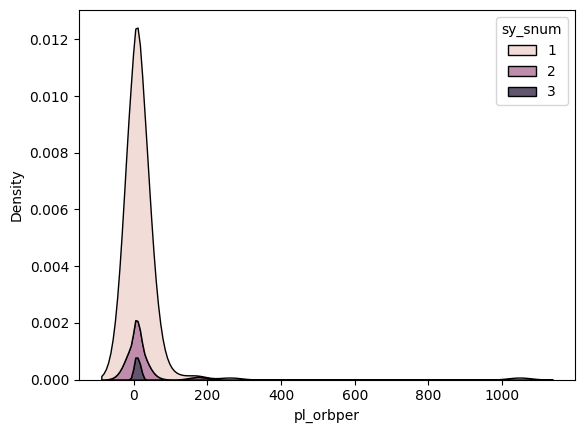

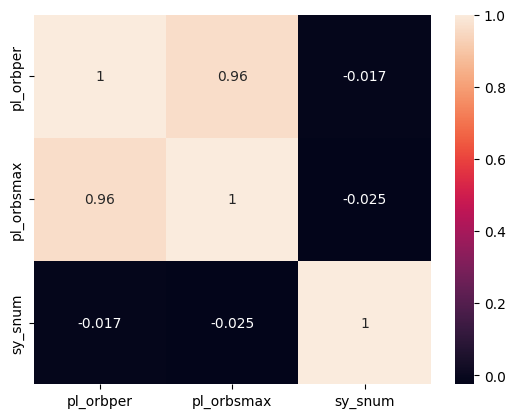

In [481]:
fig = plt.figure(1)
ax = fig.gca()
sns.kdeplot(data=data,x="pl_orbsmax",hue="sy_snum",multiple="stack")
fig = plt.figure(2)
ax = fig.gca()
sns.kdeplot(data=data,x="pl_orbper",hue="sy_snum",multiple="stack")
fig = plt.figure(3)
ax = fig.gca()
cor = data[["pl_orbper","pl_orbsmax","sy_snum"]].corr(numeric_only=True)
sns.heatmap(cor,annot=True)

Quizás no. Después de todo, una mayor masa en el centro del sistema implica mayor fuerza gravitatoria, lo que se podría traducir en mayor velocidad y menor periodo. También podemos ver el semieje mayor del planeta y su excentricidad.

Text(1.2, 0.03, 'Excentricidad Tierra')

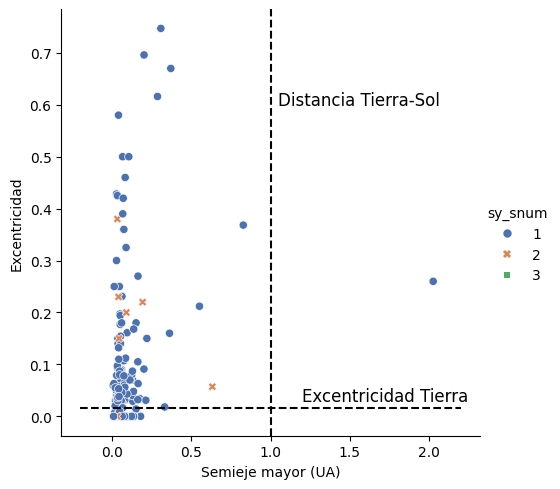

In [482]:
p = sns.relplot(x="pl_orbsmax",y="pl_orbeccen",data=data,hue="sy_snum",style="sy_snum",palette="deep")
p.set_axis_labels(x_var="Semieje mayor (UA)",y_var="Excentricidad")
plt.axvline(x=1,color="k",linestyle="--",label="Distancia Tierra-Sol")
plt.hlines(0.0167,-0.2,2.2,colors="k",linestyles="--")
plt.text(1.05,0.6,"Distancia Tierra-Sol",fontsize=12)
plt.text(1.2,0.03,"Excentricidad Tierra",fontsize=12)

Salvo excepciones, parece que todos los planetas se encuentran mucho más cerca de su estrella que la Tierra, además de tener una excentricidad superior.

Veamos ahora las estrellas de los sistemas.

In [483]:
data["st_spectype"].value_counts()

st_spectype
K4 V        12
F            6
K0 V         6
G9 V         5
M0 V         5
            ..
M4.0         1
M3+/-1       1
M1+/-0.5     1
F2 V         1
F7           1
Name: count, Length: 77, dtype: int64

Hay demasiados tipos para ser representados en un histograma. Por lo tanto, podríamos agrupar las estrellas de acuerdo al orden de magnitud OBAFGKM, reduciendo el número de categorías pero perdiendo información en el proceso. Sin embargo, para los propósitos de este trabajo, será un sacrificio necesario.

In [484]:
index = 0
for i in data["st_spectype"]:
    data.iloc[index,15] = i[0] #15 = st_spectype
    index +=1
    
data["st_spectype"].value_counts()

st_spectype
M    56
K    56
G    40
F    20
A     2
B     1
Name: count, dtype: int64

La categoría de las estrellas depende de su luminosidad, y esta a su vez depende del tamaño y la temperatura de la estrella. Veamos esta relación.

Text(0, 5830, 'T solar')

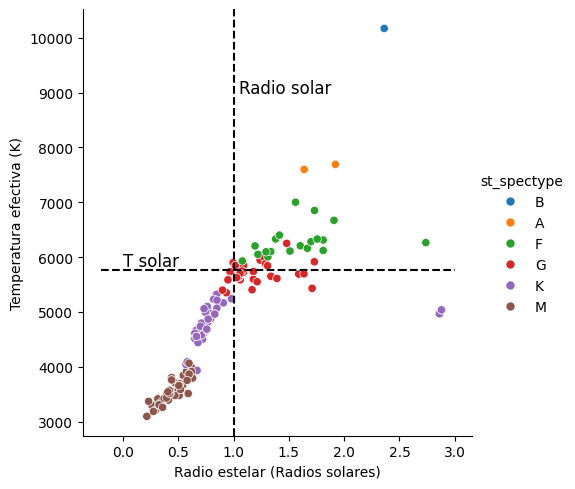

In [485]:
hue_order=["B","A","F","G","K","M"]
p = sns.relplot(x="st_rad",y="st_teff",data=data,hue="st_spectype",hue_order=hue_order)
p.set_axis_labels(x_var="Radio estelar (Radios solares)",y_var="Temperatura efectiva (K)")
plt.axvline(x=1,color="k",linestyle="--",label="Radio solar")
plt.hlines(5772,-0.2,3,colors="k",linestyles="--")
plt.text(1.05,9000,"Radio solar",fontsize=12)
plt.text(0,5830,"T solar",fontsize=12)

Tal y como dice la categoría, cuanto mayor es el radio y la temperatura de las estrellas, mayor es su luminosidad, en orden OBAFGKM. 

Tenemos también acceso a los datos de metalicidad de las estrellas. Se usan diferentes índices indicados en la columna st_metratio, pero en todos los casos se trata del logaritmo del cociente entre la abundancia de metales en la estrella y la abundancia solar. Los objetos más pobres en metales (todo lo que no sea hidrógeno o helio) tendrán un valor negativo (-1 = 10 veces menos metal que el Sol) y viceversa.

<Axes: xlabel='st_met', ylabel='Density'>

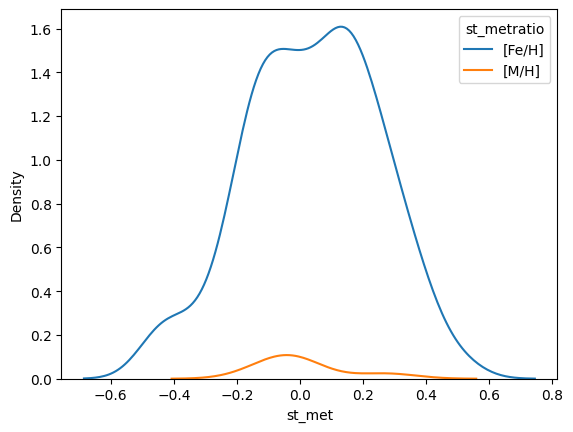

In [486]:
sns.kdeplot(data=data,x="st_met",hue="st_metratio")

Se puede ver que la mayoría de las estrellas tienen una metalicidad similar a la del Sol.

Por último, dibujemos un mapa estelar que represente dónde se encuentran los sistemas con respecto al nuestro

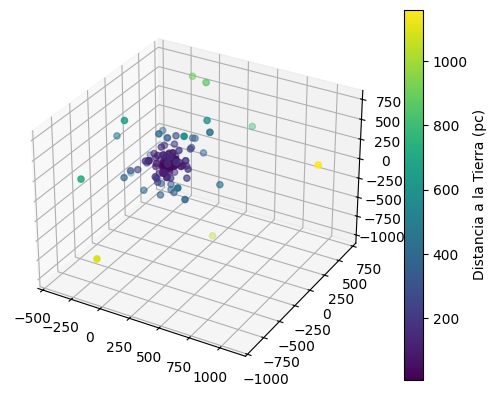

In [488]:
x = pd.Series(data["sy_dist"]*np.cos(data["ra"])*np.sin(data["dec"]),name="x")
y = pd.Series(data["sy_dist"]*np.sin(data["ra"])*np.sin(data["dec"]),name="y")
z = pd.Series(data["sy_dist"]*np.cos(data["dec"]),name="z")

fig = plt.figure()
ax = plt.axes(projection='3d')

p = ax.scatter(x,y,z,c=data["sy_dist"])

fig.colorbar(p,label="Distancia a la Tierra (pc)")

La mayoría de los sistemas se encuentran a menos de 200 parsec de nosotros.